In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

In [ ]:
df = pd.read_parquet("../data/processed/cleaned_survey_data.parquet")

# Map agreement scale to integers
agreement_mapping = {'Strongly disagree':1, 'Somewhat disagree':2, 'Neither agree nor disagree':3, 'Somewhat agree':4, 'Strongly agree':5}
for col in ['post_dis_AI_trust_1', 'satis1', 'satis2']:
    df[col] = df[col].map(agreement_mapping)

In [ ]:
# Affective polarization measures
df['post_ingroup_love'] = df.apply(
    lambda row: row['post_feel_dem_1'] if row['ingroup'] == "Democrat" else row['post_feel_rep_1'],
    axis=1
)

df['post_outgroup_hate'] = df.apply(
    lambda row: row['post_feel_rep_1'] if row['ingroup'] == "Democrat" else row['post_feel_dem_1'],
    axis=1
)

df['affective_polarization'] = df['post_ingroup_love'] - df['post_outgroup_hate']

# Perceived (issue) polarization
df['perceived_issue_polarization'] = abs(
    df['post_issue_meta_dem_1'] - df['post_issue_meta_rep_1']
)

df['ingroup_homogeneity'] = df.apply(
    lambda row: abs(row['post_issue_1'] - row['post_issue_meta_dem_1'])
                if row['ingroup'] == "Democrat"
                else abs(row['post_issue_1'] - row['post_issue_meta_rep_1']),
    axis=1
)

df['outgroup_extremity'] = df.apply(
    lambda row: abs(row['post_issue_1'] - row['post_issue_meta_rep_1'])
                if row['ingroup'] == "Democrat"
                else abs(row['post_issue_1'] - row['post_issue_meta_dem_1']),
    axis=1
)

# Issue-based persuasion
df['persuasion'] = df.apply(
    lambda row: row['post_issue_1'] - row['pre_issue_1']
                if row['pre_issue_1'] <= 50
                else row['pre_issue_1'] - row['post_issue_1'],
    axis=1
)

# Secondary - Anti-Democratic Attitudes
df['anti_democratic_1'] = df[['post_supviol1_1', 'post_supviol2_1']].mean(axis=1)
df['anti_democratic_2'] = df[['post_supundem1_1', 'post_supundem2_1']].mean(axis=1)

# Behavioral intention (Future willingness to engage)
df['future_willingness'] = df['post_dis_AI_trust_1']

# Tertiary - Discussion Quality
df['discussion_satisfaction'] = df[['satis1', 'satis2']].mean(axis=1)

In [4]:
# Create derived variables
df['age'] = df['Age']

df['male'] = (df['Sex'] == "Male").astype(int)

df['hispanic'] = (~df['Ethnicity'].isin([
    "No, not of Hispanic, Latino, or Spanish origin",
    " Prefer not to say"
])).astype(int)

df['nonwhite'] = (df['Race'] != "White").astype(int)

df['college_grad'] = df['Education'].isin([
    "Bachelor's degree (for example: BA, AB, BS)",
    "Doctorate degree (for example: PhD, EdD)",
    "Master's degree (for example: MA, MS, MEng, MEd, MSW, MBA)",
    "Professional degree (for example: MD, DDS, DVM, LLB, JD)"
]).astype(int)

# ideology (reverse-code)
ideology_mapping = {"Very liberal":1, "Somewhat liberal":2, "Slightly liberal":3, "Moderate; middle of the road":4, "Slightly conservative":5, "Somewhat conservative":6, "Very conservative":7}
df['ideology'] = df['ideology'].map(ideology_mapping)
df['ideology'] = 8 - df['ideology']

# Affective polarization measures
df['pre_ingroup_love'] = df.apply(
    lambda row: row['pre_feel_dem_1'] if row['ingroup'] == "Democrat" else row['pre_feel_rep_1'],
    axis=1
)

df['pre_outgroup_hate'] = df.apply(
    lambda row: row['pre_feel_rep_1'] if row['ingroup'] == "Democrat" else row['pre_feel_dem_1'],
    axis=1
)

df['pre_affective_polarization'] = df['pre_ingroup_love'] - df['pre_outgroup_hate']

# Issue polarization measures
df['pre_perceived_issue_polarization'] = abs(
    df['pre_issue_meta_dem_1'] - df['pre_issue_meta_rep_1']
)

df['pre_ingroup_homogeneity'] = df.apply(
    lambda row: abs(row['pre_issue_1'] - row['pre_issue_meta_dem_1']) 
                if row['ingroup'] == "Democrat" 
                else abs(row['pre_issue_1'] - row['pre_issue_meta_rep_1']),
    axis=1
)

df['pre_outgroup_extremity'] = df.apply(
    lambda row: abs(row['pre_issue_1'] - row['pre_issue_meta_rep_1'])
                if row['ingroup'] == "Democrat"
                else abs(row['pre_issue_1'] - row['pre_issue_meta_dem_1']),
    axis=1
)

In [5]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import numpy as np

def lasso_covariate_selection(df, outcome, predictors):
    """
    Perform LASSO covariate selection using cross-validation.
    
    Args:
        df: DataFrame containing the data
        outcome: Name of the outcome variable
        predictors: List of predictor variable names
        
    Returns:
        List of selected variable names with non-zero coefficients
    """
    # Preprocess: Filter and select relevant columns
    cols_to_select = predictors + ['treatment', outcome]
    df_filtered = df[cols_to_select].copy()
    
    # Drop NA values (Lasso cannot deal with NA)
    df_filtered = df_filtered.dropna()
    
    # Extract outcome variable
    y = df_filtered[outcome].values
    
    # Create matrix of predictor variables
    # Use pd.get_dummies to convert categorical variables to dummy indicators
    X = pd.get_dummies(df_filtered[predictors], drop_first=False)
    
    # Store column names for later
    feature_names = X.columns.tolist()
    
    # Perform k-fold cross-validation to find optimal alpha (lambda) value (k=10)
    np.random.seed(2025)
    lasso_cv = LassoCV(cv=10, random_state=2025, max_iter=10000)
    lasso_cv.fit(X, y)
    
    # Best alpha that minimizes test MSE
    best_alpha = lasso_cv.alpha_
    
    # Get coefficients from the best model
    coefficients = lasso_cv.coef_
    
    # Extract selected covariates (non-zero coefficients)
    selected_variables = [
        feature_names[i] 
        for i in range(len(coefficients)) 
        if coefficients[i] != 0
    ]
    
    print(f"Best alpha: {best_alpha:.6f}")
    print(f"Selected {len(selected_variables)} variables out of {len(feature_names)}")
    
    # Return selected variables as a list
    return selected_variables

In [6]:
def prepare_ols_data(df, outcome, treatment, predictors, selected_vars, block="block"):
    """
    Prepare data for OLS regression analysis.
    
    Args:
        df: DataFrame containing the data
        outcome: Name of the outcome variable
        treatment: Name of the treatment variable
        predictors: List of predictor variable names
        selected_vars: List of selected variable names from lasso_covariate_selection()
        block: Name of the block variable (default: "block")
        
    Returns:
        DataFrame with outcome, treatment indicators, block, and selected covariates
    """
    # Filter and select relevant columns
    cols_to_select = predictors + [treatment, outcome, block]
    df_filtered = df[cols_to_select].copy()
    
    # Create matrix of predictor variables (convert categorical to dummy indicators)
    X = pd.get_dummies(df_filtered[predictors], drop_first=False)
    
    # Create treatment variables
    df_filtered['Outgroup'] = df_filtered[treatment].str.contains('outgroup', case=False, na=False).astype(int)
    df_filtered['Disagree'] = df_filtered[treatment].str.contains('disagree', case=False, na=False).astype(int)
    
    # Select only the covariates that were selected by LASSO
    covariates = X[selected_vars].copy()
    
    # Combine outcome, treatment, block, and covariates into a single DataFrame
    data_selected = pd.DataFrame({
        'y': df_filtered[outcome],
        'Outgroup': df_filtered['Outgroup'].astype('category'),
        'Disagree': df_filtered['Disagree'].astype('category'),
        'Block': df_filtered[block].astype('category')
    })
    
    # Add covariates columns
    data_selected = pd.concat([data_selected, covariates], axis=1)
    
    # Reset index to avoid issues
    data_selected = data_selected.reset_index(drop=True)
    
    return data_selected

In [7]:
# Create block variable based on partisanship and pre_trust_in_AI
def assign_block(row):
    if row['ingroup'] == "Democrat" and row['pre_AI_trust'] == "Yes":
        return "block1"
    elif row['ingroup'] == "Republican" and row['pre_AI_trust'] == "Yes":
        return "block2"
    elif row['ingroup'] == "Democrat" and row['pre_AI_trust'] == "No":
        return "block3"
    elif row['ingroup'] == "Republican" and row['pre_AI_trust'] == "No":
        return "block4"
    else:
        return None

df['block'] = df.apply(assign_block, axis=1).astype('category')

### Affective Polarization

In [8]:
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import RegressionResults
import statsmodels.api as sm

predictors = ["nonwhite", "age", "college_grad", "male",
            "ideology", "pre_ingroup_love", "pre_outgroup_hate", 
            "pre_affective_polarization", "pre_perceived_issue_polarization",
            "pre_ingroup_homogeneity", "pre_outgroup_extremity"]

treatment = "treatment"
data = {}
for outcome in ["post_ingroup_love", "post_outgroup_hate", "affective_polarization"]:
    # 1) Prepare data for OLS
    selected_vars = lasso_covariate_selection(df, outcome, predictors)
    data_for_ols = prepare_ols_data(df, outcome, treatment, predictors, selected_vars, block="block")

    # 2) Fit the 2×2 interaction model with Block and selected covariates
    #    Reference cell is Outgroup = 0 (Ingroup) & Disagree = 0 (Agree) = "Ingroup–Agree"
    #    Using HC2 robust standard errors

    # Build formula: y ~ Outgroup * Disagree + Block + all other covariates
    covariate_cols = [col for col in data_for_ols.columns if col not in ['y', 'Outgroup', 'Disagree', 'Block']]
    formula = 'y ~ Outgroup * Disagree + C(Block)'
    if covariate_cols:
        formula += ' + ' + ' + '.join(covariate_cols)

    print("Regression formula:", formula)
    print("\n" + "="*80)

    # Fit OLS model
    model = smf.ols(formula, data=data_for_ols).fit()

    # Get robust standard errors (HC2)
    h1a_1 = model.get_robustcov_results(cov_type='HC2')

    # Display results
    print(h1a_1.summary())
    print("\n" + "="*80)
    print("\nKey coefficients:")

    # Print all parameter names to see the exact naming convention
    print("\nAll parameters in the model:")
    for i, param_name in enumerate(h1a_1.model.exog_names):
        print(f"  {param_name}: {h1a_1.params[i]:.4f} (p={h1a_1.pvalues[i]:.4f})")

    # 3) Get cell means from the 2×2 design
    #      (Outgroup=0,Disagree=0) = Ingroup–Agree
    #      (Outgroup=0,Disagree=1) = Ingroup–Disagree
    #      (Outgroup=1,Disagree=0) = Outgroup–Agree
    #      (Outgroup=1,Disagree=1) = Outgroup–Disagree

    # Calculate predicted means for each treatment condition
    # Set all covariates to their means and blocks to reference category
    mean_data = data_for_ols[covariate_cols].mean().to_dict() if covariate_cols else {}

    # Create prediction dataframe for the 4 treatment conditions
    pred_data = pd.DataFrame({
        'Outgroup': [0, 0, 1, 1],
        'Disagree': [0, 1, 0, 1],
        'Block': [data_for_ols['Block'].mode()[0]] * 4  # Use most common block
    })

    # Add mean values for covariates
    for col in covariate_cols:
        pred_data[col] = mean_data[col]

    # Get predictions
    pred_data['emmean'] = h1a_1.predict(pred_data)

    # Calculate standard errors for predictions
    pred_data['SE'] = h1a_1.get_prediction(pred_data).se_mean

    # Add condition labels
    pred_data['Condition'] = ['Ingroup-Agree', 'Ingroup-Disagree', 'Outgroup-Agree', 'Outgroup-Disagree']

    print("------------------------------", outcome, "------------------------------")
    print("\n" + "="*80)
    print("\nEstimated Marginal Means (EMMs):")
    print(pred_data[['Condition', 'Outgroup', 'Disagree', 'emmean', 'SE']])
    data[outcome] = pred_data

Best alpha: 3.503457
Selected 4 variables out of 11
Regression formula: y ~ Outgroup * Disagree + C(Block) + pre_ingroup_love + pre_perceived_issue_polarization + pre_ingroup_homogeneity + pre_outgroup_extremity

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     887.6
Date:                Fri, 24 Oct 2025   Prob (F-statistic):               0.00
Time:                        02:44:52   Log-Likelihood:                -6805.6
No. Observations:                1957   AIC:                         1.363e+04
Df Residuals:                    1946   BIC:                         1.369e+04
Df Model:                          10                                         
Covariance Type:                  HC2                                       

/tmp/ipykernel_525349/1713212358.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])
/tmp/ipykernel_525349/1713212358.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])
/tmp/ipykernel_525349/1713212358.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])


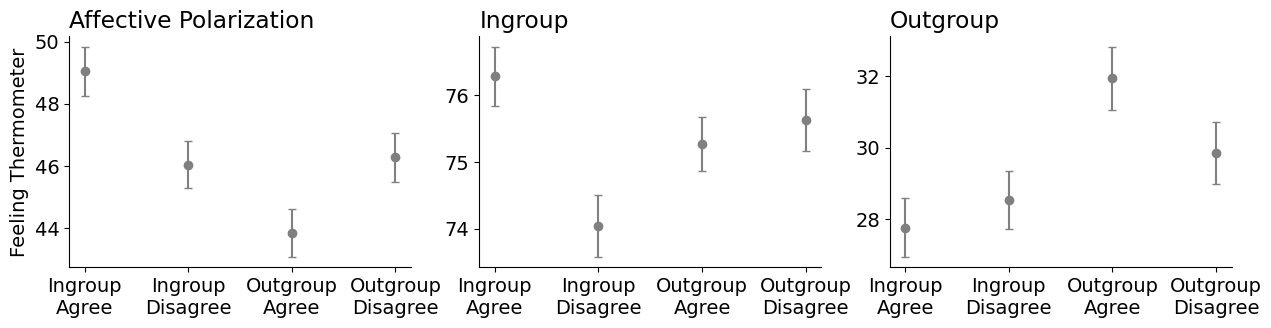

In [9]:
fig, axs = plt.subplots(1,3,figsize=(15,3))

for outcome, ax, title in zip(["affective_polarization", "post_ingroup_love", "post_outgroup_hate"], 
                       axs,
                       ['Affective Polarization', 'Ingroup', 'Outgroup']):
    pred_data = data[outcome]

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.errorbar(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'],
                pred_data['emmean'],
                yerr=pred_data['SE'],
                fmt='o',
                color='gray',
                capsize=3)
    ax.set_xticklabels([])
    ax.set_title(title, loc='left')
    ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])

axs[0].set_ylabel('Feeling Thermometer')
fig.savefig('../figures/feeling_thermometer_emms.png', dpi=600, transparent=True, bbox_inches='tight')
fig.savefig('../figures/feeling_thermometer_emms.pdf', transparent=True, bbox_inches='tight')

### Ingroup Homogeneity / Outgroup Extremity

In [10]:
outcomes = ["perceived_issue_polarization", "ingroup_homogeneity", "outgroup_extremity"]

In [11]:
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import RegressionResults
import statsmodels.api as sm

predictors = ["nonwhite", "age", "college_grad", "male",
            "ideology", "pre_ingroup_love", "pre_outgroup_hate", 
            "pre_affective_polarization", "pre_perceived_issue_polarization",
            "pre_ingroup_homogeneity", "pre_outgroup_extremity"]

treatment = "treatment"
data = {}
for outcome in outcomes:
    # 1) Prepare data for OLS
    selected_vars = lasso_covariate_selection(df, outcome, predictors)
    data_for_ols = prepare_ols_data(df, outcome, treatment, predictors, selected_vars, block="block")

    # 2) Fit the 2×2 interaction model with Block and selected covariates
    #    Reference cell is Outgroup = 0 (Ingroup) & Disagree = 0 (Agree) = "Ingroup–Agree"
    #    Using HC2 robust standard errors

    # Build formula: y ~ Outgroup * Disagree + Block + all other covariates
    covariate_cols = [col for col in data_for_ols.columns if col not in ['y', 'Outgroup', 'Disagree', 'Block']]
    formula = 'y ~ Outgroup * Disagree + C(Block)'
    if covariate_cols:
        formula += ' + ' + ' + '.join(covariate_cols)

    print("Regression formula:", formula)
    print("\n" + "="*80)

    # Fit OLS model
    model = smf.ols(formula, data=data_for_ols).fit()

    # Get robust standard errors (HC2)
    h1a_1 = model.get_robustcov_results(cov_type='HC2')

    # Display results
    print(h1a_1.summary())
    print("\n" + "="*80)
    print("\nKey coefficients:")

    # Print all parameter names to see the exact naming convention
    print("\nAll parameters in the model:")
    for i, param_name in enumerate(h1a_1.model.exog_names):
        print(f"  {param_name}: {h1a_1.params[i]:.4f} (p={h1a_1.pvalues[i]:.4f})")

    # 3) Get cell means from the 2×2 design
    #      (Outgroup=0,Disagree=0) = Ingroup–Agree
    #      (Outgroup=0,Disagree=1) = Ingroup–Disagree
    #      (Outgroup=1,Disagree=0) = Outgroup–Agree
    #      (Outgroup=1,Disagree=1) = Outgroup–Disagree

    # Calculate predicted means for each treatment condition
    # Set all covariates to their means and blocks to reference category
    mean_data = data_for_ols[covariate_cols].mean().to_dict() if covariate_cols else {}

    # Create prediction dataframe for the 4 treatment conditions
    pred_data = pd.DataFrame({
        'Outgroup': [0, 0, 1, 1],
        'Disagree': [0, 1, 0, 1],
        'Block': [data_for_ols['Block'].mode()[0]] * 4  # Use most common block
    })

    # Add mean values for covariates
    for col in covariate_cols:
        pred_data[col] = mean_data[col]

    # Get predictions
    pred_data['emmean'] = h1a_1.predict(pred_data)

    # Calculate standard errors for predictions
    pred_data['SE'] = h1a_1.get_prediction(pred_data).se_mean

    # Add condition labels
    pred_data['Condition'] = ['Ingroup-Agree', 'Ingroup-Disagree', 'Outgroup-Agree', 'Outgroup-Disagree']

    print("------------------------------", outcome, "------------------------------")
    print("\n" + "="*80)
    print("\nEstimated Marginal Means (EMMs):")
    print(pred_data[['Condition', 'Outgroup', 'Disagree', 'emmean', 'SE']])
    data[outcome] = pred_data

Best alpha: 1.840095
Selected 6 variables out of 11
Regression formula: y ~ Outgroup * Disagree + C(Block) + age + pre_outgroup_hate + pre_affective_polarization + pre_perceived_issue_polarization + pre_ingroup_homogeneity + pre_outgroup_extremity

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     445.5
Date:                Fri, 24 Oct 2025   Prob (F-statistic):               0.00
Time:                        02:45:15   Log-Likelihood:                -8433.7
No. Observations:                1957   AIC:                         1.689e+04
Df Residuals:                    1944   BIC:                         1.697e+04
Df Model:                          12                                         
Covariance Type:                  HC2   

/tmp/ipykernel_525349/2004440740.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])
/tmp/ipykernel_525349/2004440740.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])
/tmp/ipykernel_525349/2004440740.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])


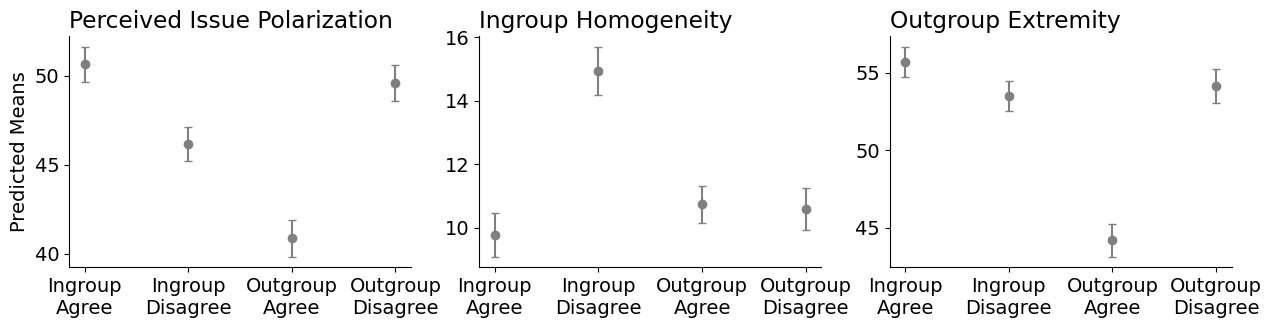

In [15]:
fig, axs = plt.subplots(1,3,figsize=(15,3))

for outcome, ax, title in zip(outcomes, 
                       axs,
                       ['Perceived Issue Polarization', 'Ingroup Homogeneity', 'Outgroup Extremity']):
    pred_data = data[outcome]

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.errorbar(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'],
                pred_data['emmean'],
                yerr=pred_data['SE'],
                fmt='o',
                color='gray',
                capsize=3)
    ax.set_xticklabels([])
    ax.set_title(title, loc='left')
    ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])

axs[0].set_ylabel('Predicted Means')
fig.savefig('../figures/perceived_issue_polarization.png', dpi=600, transparent=True, bbox_inches='tight')
fig.savefig('../figures/perceived_issue_polarization.pdf', transparent=True, bbox_inches='tight')

### Willigness to Discuss & Conversation Satisfaction

In [16]:
outcomes = ['future_willingness', 'discussion_satisfaction']

In [17]:
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import RegressionResults
import statsmodels.api as sm

predictors = ["nonwhite", "age", "college_grad", "male",
            "ideology", "pre_ingroup_love", "pre_outgroup_hate", 
            "pre_affective_polarization", "pre_perceived_issue_polarization",
            "pre_ingroup_homogeneity", "pre_outgroup_extremity"]

treatment = "treatment"
data = {}
for outcome in outcomes:
    # 1) Prepare data for OLS
    selected_vars = lasso_covariate_selection(df, outcome, predictors)
    data_for_ols = prepare_ols_data(df, outcome, treatment, predictors, selected_vars, block="block")

    # 2) Fit the 2×2 interaction model with Block and selected covariates
    #    Reference cell is Outgroup = 0 (Ingroup) & Disagree = 0 (Agree) = "Ingroup–Agree"
    #    Using HC2 robust standard errors

    # Build formula: y ~ Outgroup * Disagree + Block + all other covariates
    covariate_cols = [col for col in data_for_ols.columns if col not in ['y', 'Outgroup', 'Disagree', 'Block']]
    formula = 'y ~ Outgroup * Disagree + C(Block)'
    if covariate_cols:
        formula += ' + ' + ' + '.join(covariate_cols)

    print("Regression formula:", formula)
    print("\n" + "="*80)

    # Fit OLS model
    model = smf.ols(formula, data=data_for_ols).fit()

    # Get robust standard errors (HC2)
    h1a_1 = model.get_robustcov_results(cov_type='HC2')

    # Display results
    print(h1a_1.summary())
    print("\n" + "="*80)
    print("\nKey coefficients:")

    # Print all parameter names to see the exact naming convention
    print("\nAll parameters in the model:")
    for i, param_name in enumerate(h1a_1.model.exog_names):
        print(f"  {param_name}: {h1a_1.params[i]:.4f} (p={h1a_1.pvalues[i]:.4f})")

    # 3) Get cell means from the 2×2 design
    #      (Outgroup=0,Disagree=0) = Ingroup–Agree
    #      (Outgroup=0,Disagree=1) = Ingroup–Disagree
    #      (Outgroup=1,Disagree=0) = Outgroup–Agree
    #      (Outgroup=1,Disagree=1) = Outgroup–Disagree

    # Calculate predicted means for each treatment condition
    # Set all covariates to their means and blocks to reference category
    mean_data = data_for_ols[covariate_cols].mean().to_dict() if covariate_cols else {}

    # Create prediction dataframe for the 4 treatment conditions
    pred_data = pd.DataFrame({
        'Outgroup': [0, 0, 1, 1],
        'Disagree': [0, 1, 0, 1],
        'Block': [data_for_ols['Block'].mode()[0]] * 4  # Use most common block
    })

    # Add mean values for covariates
    for col in covariate_cols:
        pred_data[col] = mean_data[col]

    # Get predictions
    pred_data['emmean'] = h1a_1.predict(pred_data)

    # Calculate standard errors for predictions
    pred_data['SE'] = h1a_1.get_prediction(pred_data).se_mean

    # Add condition labels
    pred_data['Condition'] = ['Ingroup-Agree', 'Ingroup-Disagree', 'Outgroup-Agree', 'Outgroup-Disagree']

    print("------------------------------", outcome, "------------------------------")
    print("\n" + "="*80)
    print("\nEstimated Marginal Means (EMMs):")
    print(pred_data[['Condition', 'Outgroup', 'Disagree', 'emmean', 'SE']])
    data[outcome] = pred_data

Best alpha: 0.212561
Selected 5 variables out of 11
Regression formula: y ~ Outgroup * Disagree + C(Block) + age + pre_ingroup_love + pre_outgroup_hate + pre_ingroup_homogeneity + pre_outgroup_extremity

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     32.19
Date:                Fri, 24 Oct 2025   Prob (F-statistic):           2.86e-63
Time:                        03:03:46   Log-Likelihood:                -2839.2
No. Observations:                1957   AIC:                             5702.
Df Residuals:                    1945   BIC:                             5769.
Df Model:                          11                                         
Covariance Type:                  HC2                                         
      

/tmp/ipykernel_525349/3842262043.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])
/tmp/ipykernel_525349/3842262043.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])


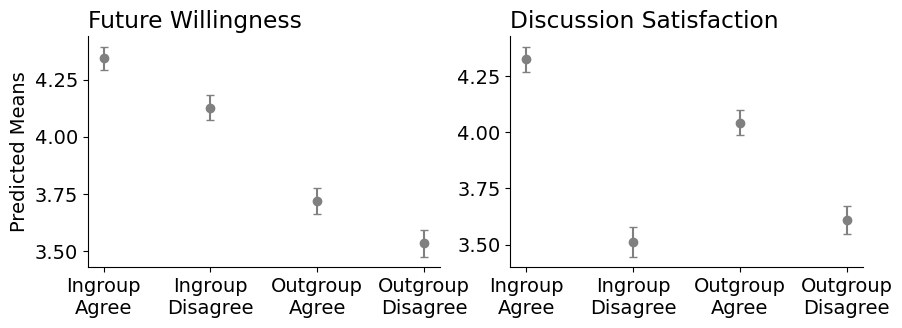

In [19]:
fig, axs = plt.subplots(1,2,figsize=(10,3))

for outcome, ax, title in zip(outcomes, 
                            axs,
                            ['Future Willingness', 'Discussion Satisfaction']):
    pred_data = data[outcome]

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.errorbar(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'],
                pred_data['emmean'],
                yerr=pred_data['SE'],
                fmt='o',
                color='gray',
                capsize=3)
    ax.set_xticklabels([])
    ax.set_title(title, loc='left')
    ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])

axs[0].set_ylabel('Predicted Means')
fig.savefig('../figures/future_willingness_and_discussion_satisfaction.png', dpi=600, transparent=True, bbox_inches='tight')
fig.savefig('../figures/future_willingness_and_discussion_satisfaction.pdf', transparent=True, bbox_inches='tight')

### Support for undemocratic practices / partisan violence

In [21]:
outcomes = ['anti_democratic_1', 'anti_democratic_2']

In [22]:
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import RegressionResults
import statsmodels.api as sm

predictors = ["nonwhite", "age", "college_grad", "male",
            "ideology", "pre_ingroup_love", "pre_outgroup_hate", 
            "pre_affective_polarization", "pre_perceived_issue_polarization",
            "pre_ingroup_homogeneity", "pre_outgroup_extremity"]

treatment = "treatment"
data = {}
for outcome in outcomes:
    # 1) Prepare data for OLS
    selected_vars = lasso_covariate_selection(df, outcome, predictors)
    data_for_ols = prepare_ols_data(df, outcome, treatment, predictors, selected_vars, block="block")

    # 2) Fit the 2×2 interaction model with Block and selected covariates
    #    Reference cell is Outgroup = 0 (Ingroup) & Disagree = 0 (Agree) = "Ingroup–Agree"
    #    Using HC2 robust standard errors

    # Build formula: y ~ Outgroup * Disagree + Block + all other covariates
    covariate_cols = [col for col in data_for_ols.columns if col not in ['y', 'Outgroup', 'Disagree', 'Block']]
    formula = 'y ~ Outgroup * Disagree + C(Block)'
    if covariate_cols:
        formula += ' + ' + ' + '.join(covariate_cols)

    print("Regression formula:", formula)
    print("\n" + "="*80)

    # Fit OLS model
    model = smf.ols(formula, data=data_for_ols).fit()

    # Get robust standard errors (HC2)
    h1a_1 = model.get_robustcov_results(cov_type='HC2')

    # Display results
    print(h1a_1.summary())
    print("\n" + "="*80)
    print("\nKey coefficients:")

    # Print all parameter names to see the exact naming convention
    print("\nAll parameters in the model:")
    for i, param_name in enumerate(h1a_1.model.exog_names):
        print(f"  {param_name}: {h1a_1.params[i]:.4f} (p={h1a_1.pvalues[i]:.4f})")

    # 3) Get cell means from the 2×2 design
    #      (Outgroup=0,Disagree=0) = Ingroup–Agree
    #      (Outgroup=0,Disagree=1) = Ingroup–Disagree
    #      (Outgroup=1,Disagree=0) = Outgroup–Agree
    #      (Outgroup=1,Disagree=1) = Outgroup–Disagree

    # Calculate predicted means for each treatment condition
    # Set all covariates to their means and blocks to reference category
    mean_data = data_for_ols[covariate_cols].mean().to_dict() if covariate_cols else {}

    # Create prediction dataframe for the 4 treatment conditions
    pred_data = pd.DataFrame({
        'Outgroup': [0, 0, 1, 1],
        'Disagree': [0, 1, 0, 1],
        'Block': [data_for_ols['Block'].mode()[0]] * 4  # Use most common block
    })

    # Add mean values for covariates
    for col in covariate_cols:
        pred_data[col] = mean_data[col]

    # Get predictions
    pred_data['emmean'] = h1a_1.predict(pred_data)

    # Calculate standard errors for predictions
    pred_data['SE'] = h1a_1.get_prediction(pred_data).se_mean

    # Add condition labels
    pred_data['Condition'] = ['Ingroup-Agree', 'Ingroup-Disagree', 'Outgroup-Agree', 'Outgroup-Disagree']

    print("------------------------------", outcome, "------------------------------")
    print("\n" + "="*80)
    print("\nEstimated Marginal Means (EMMs):")
    print(pred_data[['Condition', 'Outgroup', 'Disagree', 'emmean', 'SE']])
    data[outcome] = pred_data

Best alpha: 0.040901
Selected 11 variables out of 11
Regression formula: y ~ Outgroup * Disagree + C(Block) + nonwhite + age + college_grad + male + ideology + pre_ingroup_love + pre_outgroup_hate + pre_affective_polarization + pre_perceived_issue_polarization + pre_ingroup_homogeneity + pre_outgroup_extremity

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     7.575
Date:                Fri, 24 Oct 2025   Prob (F-statistic):           1.34e-17
Time:                        04:11:13   Log-Likelihood:                -8637.5
No. Observations:                1956   AIC:                         1.731e+04
Df Residuals:                    1939   BIC:                         1.740e+04
Df Model:                          16                  

/home/exouser/anaconda3/envs/llm/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 16
  warnings.warn('covariance of constraints does not have full '
/home/exouser/anaconda3/envs/llm/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 16
  warnings.warn('covariance of constraints does not have full '


/tmp/ipykernel_525349/1466602513.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])
/tmp/ipykernel_525349/1466602513.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])


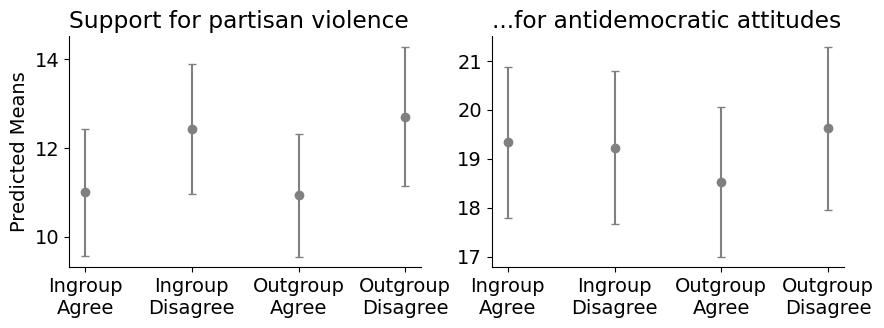

In [26]:
fig, axs = plt.subplots(1,2,figsize=(10,3))

for outcome, ax, title in zip(outcomes, 
                            axs,
                            ['Support for partisan violence', '...for antidemocratic attitudes']):
    pred_data = data[outcome]

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.errorbar(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'],
                pred_data['emmean'],
                yerr=pred_data['SE'],
                fmt='o',
                color='gray',
                capsize=3)
    ax.set_xticklabels([])
    ax.set_title(title, loc='left')
    ax.set_xticklabels(['Ingroup\nAgree','Ingroup\nDisagree','Outgroup\nAgree','Outgroup\nDisagree'])

axs[0].set_ylabel('Predicted Means')
fig.savefig('../figures/anti_democratic_attitudes.png', dpi=600, transparent=True, bbox_inches='tight')
fig.savefig('../figures/anti_democratic_attitudes.pdf', transparent=True, bbox_inches='tight')